# Preliminary EXIOBASE disaggregation test

**Purpose:** Demonstrate technical feasibility of splitting Sweden into "Stockholm" and "Rest of Sweden" within EXIOBASE 3, then computing production-based and consumption-based accounts for both sub-regions.

This notebook uses **proxy weights** (population share, rough sector estimates) rather than the full Anthesis data collection. It is a proof-of-concept for the April 27 workshop, not a final analysis.

**EXIOBASE version:** 3.10.1 (pxp, year 2024), published Mar 23, 2026.

**System size:** 200 products × 49 regions = 9,800. After splitting Sweden: 200 products × 50 regions = 10,000.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging
import time

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

## Configuration

In [2]:
# Path to EXIOBASE 3 zip file (adjust to your local setup).
EXIOBASE_PATH = Path("C:/EXIOBASE3/IOT_2024_pxp.zip")
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

# Output directory for results.
OUTPUT_DIR = Path("./results_stockholm_test")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sweden's country code in EXIOBASE.
SWEDEN_CODE = "SE"

# New region codes for the split.
STOCKHOLM_CODE = "SE_STHLM"
REST_OF_SWEDEN_CODE = "SE_REST"

# Stockholm's approximate share of Swedish final demand
# (income-weighted population share: ~24% of population but higher income).
DEMAND_WEIGHT_STHLM = 0.28

# Base year.
BASE_YEAR = 2024

## Step 1: Define proxy weights for Stockholm

For the full analysis, these weights come from Dun & Bradstreet / SCB data on sector-level input goods in Stockholm vs. Sweden. For this test, we use rough proxies based on Stockholm's known economic profile.

In [3]:
def build_proxy_weights():
    """
    Build proxy sector weights for Stockholm.

    Each weight represents Stockholm's share of a sector's national output.
    They do NOT sum to 1 across sectors. Each is independent:
    "Stockholm accounts for X% of this sector nationally."
    """
    default_weight = 0.24

    overrides = {
        # Stockholm has relatively MORE of these (above population share):
        "financial": 0.45,
        "insurance": 0.40,
        "real estate": 0.35,
        "computer": 0.40,
        "telecommunication": 0.35,
        "publishing": 0.35,
        "research": 0.35,
        "other business": 0.30,
        "public admin": 0.25,
        "education": 0.25,
        "health": 0.25,
        "construction": 0.30,
        "hotel": 0.28,
        "restaurant": 0.28,
        "wholesale": 0.30,
        "retail": 0.28,
        "air transport": 0.40,

        # Stockholm has relatively LESS of these (below population share):
        "mining": 0.02,
        "quarrying": 0.05,
        "forestry": 0.02,
        "logging": 0.02,
        "fishing": 0.03,
        "agriculture": 0.05,
        "cultivation": 0.05,
        "crop": 0.05,
        "cattle": 0.03,
        "pulp": 0.01,
        "paper": 0.03,
        "wood": 0.05,
        "basic iron": 0.01,
        "basic precious": 0.01,
        "basic non-ferrous": 0.02,
        "electricity": 0.15,
        "steam": 0.20,
    }

    return default_weight, overrides


def assign_weights(sectors, default_weight, overrides):
    """Assign a Stockholm share weight to each EXIOBASE sector via substring matching."""
    weights = {}
    for sector in sectors:
        sector_lower = sector.lower()
        matched = False
        for substring, weight in overrides.items():
            if substring in sector_lower:
                weights[sector] = weight
                matched = True
                break
        if not matched:
            weights[sector] = default_weight
    return weights

## Step 2: Load EXIOBASE

pymrio parses the raw transaction matrix (Z) and final demand (Y) but does not pre-compute the technical coefficient matrix (A). We call `calc_system()` to derive A and the Leontief inverse L.

In [4]:
def load_exiobase(path):
    """Load EXIOBASE 3, compute A and L, and verify satellite extensions."""
    log.info(f"Loading EXIOBASE from {path} ...")
    t0 = time.time()

    exio = pymrio.parse_exiobase3(path=path)

    log.info(f"Parsed in {time.time() - t0:.1f}s. Computing A matrix ...")
    exio.calc_system()

    log.info(f"A matrix shape: {exio.A.shape}")
    log.info(f"Y matrix shape: {exio.Y.shape}")
    log.info(f"Regions: {exio.get_regions().tolist()[:5]} ... "
             f"({len(exio.get_regions())} total)")
    log.info(f"Sectors per region: {len(exio.get_sectors())}")

    # Log available extensions.
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            log.info(f"Extension '{ext_name}': {ext.F.shape[0]} stressors")
        else:
            log.warning(f"Extension '{ext_name}': NOT FOUND")

    return exio

In [20]:
exio = load_exiobase(EXIOBASE_PATH)

2026-04-14 09:28:41,551 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-14 09:28:41,609 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-14 09:28:41,612 INFO 20260414 09:28:41 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-14 09:28:41,614 INFO Load data from Z.txt
2026-04-14 09:29:05,826 INFO Load data from Y.txt
2026-04-14 09:29:06,190 INFO Load data from x.txt
2026-04-14 09:29:06,204 INFO Load data from unit.txt
2026-04-14 09:29:06,233 INFO Load data from water/F.txt
2026-04-14 09:29:06,631 INFO Load data from water/F_Y.txt
2026-04-14 09:29:06,646 INFO Load data from water/unit.txt
2026-04-14 09:29:06,652 INFO 20260414 09:29:06 - FILEIO -  Added satellite account from water
2026-04-14 09:29:06,659 INFO Load data from factor_inputs/F.txt
2026-04-14 09:29:07,025 INFO Load data from factor_inputs/F_Y.txt
2026-04-14 09:29:07,037 INFO Load data from factor_inputs/unit.txt
2026-04-14 09:29:07,041 INFO 20260414 09:29:07 - FILEIO 

## Material and GHG category mappings

Map the 62 EXIOBASE material extraction rows to the four Anthesis primary categories (biomass, fossil, metals, minerals). Also define GHG aggregation with GWP-100 conversion.

In [ ]:
# =============================================================================
# Material rows -> Anthesis four primary categories
# =============================================================================

MATERIAL_CATEGORY_MAP = {
    # BIOMASS (rows 0-22): all crops, forestry, fishery
    "biomass": list(range(0, 23)),
    # FOSSIL (rows 23-32): all fossil fuels
    "fossil": list(range(23, 33)),
    # METALS (rows 33-47): all metal ores
    "metals": list(range(33, 48)),
    # MINERALS (rows 48-61): all non-metallic minerals
    "minerals": list(range(48, 62)),
    # RECYCLED: no direct equivalent in EXIOBASE extraction satellites.
    "recycled": [],
}


def aggregate_material_categories(F_material):
    """
    Aggregate the 62 EXIOBASE material extraction rows
    into the four Anthesis primary categories.

    Works on any DataFrame with the same 62-row index:
    F matrices, D_cba, D_pba, or single-region slices.
    """
    row_names = F_material.index.tolist()
    result = {}
    for category, row_indices in MATERIAL_CATEGORY_MAP.items():
        if not row_indices:
            continue
        selected_rows = [row_names[i] for i in row_indices]
        result[category] = F_material.loc[selected_rows].sum(axis=0)
    return pd.DataFrame(result).T


# Verify mapping covers all 62 rows with no overlaps.
all_indices = []
for cat, indices in MATERIAL_CATEGORY_MAP.items():
    all_indices.extend(indices)
assert sorted(all_indices) == list(range(62)), "Mapping does not cover all 62 rows!"
assert len(all_indices) == len(set(all_indices)), "Overlapping indices!"
print("Material category mapping OK: 62 rows -> 4 categories")


# =============================================================================
# GHG emission rows -> aggregated GHG (CO2e)
# =============================================================================

# Global Warming Potentials (AR5 100-year values).
GWP = {
    "CO2": 1,
    "CH4": 28,
    "N2O": 265,
    "SF6": 23500,
    "HFC": 1, # EXIOBASE 3: "HFC - air" is stored as kg CO2e, not kg HFC
    "PFC": 1, # EXIOBASE 3: "PFC - air" is stored as kg CO2e, not kg PFC
}

# Rows included in FOSSIL GHG total (excluding biogenic).
GHG_FOSSIL_ROWS = {
    "CO2": [
        "CO2 - combustion - air",
        "CO2 - non combustion - Cement production - air",
        "CO2 - non combustion - Lime production - air",
        "CO2 - waste - fossil - air",
    ],
    "CH4": [
        "CH4 - combustion - air",
        "CH4 - non combustion - Extraction/production of (natural) gas - air",
        "CH4 - non combustion - Extraction/production of crude oil - air",
        "CH4 - non combustion - Mining of antracite - air",
        "CH4 - non combustion - Mining of bituminous coal - air",
        "CH4 - non combustion - Mining of coking coal - air",
        "CH4 - non combustion - Mining of lignite (brown coal) - air",
        "CH4 - non combustion - Mining of sub-bituminous coal - air",
        "CH4 - non combustion - Oil refinery - air",
        "CH4 - agriculture - air",
        "CH4 - waste - air",
    ],
    "N2O": [
        "N2O - combustion - air",
        "N2O - agriculture - air",
    ],
    "SF6": ["SF6 - air"],
    "HFC": ["HFC - air"],
    "PFC": ["PFC - air"],
}

GHG_BIOGENIC_ROWS = [
    "CO2_bio - combustion - air",
    "CH4_bio - combustion - air",
    "N2O_bio - combustion - air",
    "CO2 - agriculture - peat decay - air",
    "CO2 - waste - biogenic - air",
]


def aggregate_ghg(F_air):
    """
    Aggregate air emission rows into fossil GHG (CO2e) and biogenic CO2e.

    Works on any DataFrame with the air_emissions 420-row index.
    """
    all_rows = F_air.index.tolist()

    fossil_total = pd.Series(0.0, index=F_air.columns)
    for gas, rows in GHG_FOSSIL_ROWS.items():
        gwp = GWP[gas]
        for row_name in rows:
            if row_name in all_rows:
                fossil_total += F_air.loc[row_name] * gwp
            else:
                print(f"  WARNING: '{row_name}' not found in air_emissions")

    bio_total = pd.Series(0.0, index=F_air.columns)
    for row_name in GHG_BIOGENIC_ROWS:
        if row_name in all_rows:
            if "CO2" in row_name:
                bio_total += F_air.loc[row_name] * 1
            elif "CH4" in row_name:
                bio_total += F_air.loc[row_name] * 28
            elif "N2O" in row_name:
                bio_total += F_air.loc[row_name] * 265

    return pd.DataFrame({
        "GHG_fossil_CO2e": fossil_total,
        "GHG_biogenic_CO2e": bio_total,
    }).T


# Verify all specified GHG rows exist.
air_rows = exio.air_emissions.F.index.tolist()
missing = []
for gas, rows in GHG_FOSSIL_ROWS.items():
    for r in rows:
        if r not in air_rows:
            missing.append(r)
for r in GHG_BIOGENIC_ROWS:
    if r not in air_rows:
        missing.append(r)

if missing:
    print(f"WARNING: {len(missing)} row(s) not found:")
    for m in missing:
        print(f"  {m}")
else:
    print("GHG row mapping OK: all specified rows found")

Material category mapping OK: 62 rows -> 4 categories
GHG row mapping OK: all specified rows found


## Sanity check: Sweden totals before disaggregation

Compare against known benchmarks:
- Sweden's total domestic material extraction: roughly 200-300 Mt/year
- Sweden's territorial GHG emissions: roughly 45-50 Mt CO2e/year

In [7]:
# Material extraction totals for Sweden.
mat_F_se = exio.material.F.loc[:, SWEDEN_CODE]
mat_agg = aggregate_material_categories(mat_F_se)
print("Sweden total material extraction (by Anthesis category):")
for cat in mat_agg.index:
    total = mat_agg.loc[cat].sum()
    print(f"  {cat:12s}: {total:>15,.2f}  (check unit)")

print()

# GHG emission totals for Sweden.
air_F_se = exio.air_emissions.F.loc[:, SWEDEN_CODE]
ghg_agg = aggregate_ghg(air_F_se)
print("Sweden total GHG emissions:")
for row in ghg_agg.index:
    total = ghg_agg.loc[row].sum()
    print(f"  {row}: {total:>15,.2f}  (check unit)")

print()
print("NOTE: EXIOBASE material units are typically kt (kilotonnes).")
print("EXIOBASE emission units are typically kt of the gas (before GWP conversion).")
print("After GWP conversion above, the GHG total is in kt CO2e.")

Sweden total material extraction (by Anthesis category):
  biomass     :       64,371.56  (check unit)
  fossil      :          200.94  (check unit)
  metals      :       85,279.54  (check unit)
  minerals    :      128,672.72  (check unit)

Sweden total GHG emissions:
  GHG_fossil_CO2e: 2,415,406,616,845.02  (check unit)
  GHG_biogenic_CO2e:  427,943,563.97  (check unit)

NOTE: EXIOBASE material units are typically kt (kilotonnes).
EXIOBASE emission units are typically kt of the gas (before GWP conversion).
After GWP conversion above, the GHG total is in kt CO2e.


## Step 3: Disaggregate Sweden into Stockholm + Rest of Sweden

**Disaggregation logic:**
- A-matrix **columns** (input recipes) are **copied** to both sub-regions. The assumption is that Stockholm's and rest-of-Sweden's sectors buy the same mix of inputs per unit of output.
- A-matrix **rows** (supply allocation) are **split by alpha**. When any sector buys from "Swedish sector i", that purchase is allocated between Stockholm and rest-of-Sweden proportionally to each sub-region's share of sector i's output.

This is the standard "proportional split" assumption in regionalized MRIO literature.

In [8]:
def disaggregate_sweden(exio, sector_weights):
    """
    Split Sweden into Stockholm and Rest-of-Sweden in the EXIOBASE system.

    Returns a new pymrio.IOSystem with A, Y, and satellite extensions
    for the expanded system (original SE replaced by SE_STHLM + SE_REST).
    """
    log.info("Starting disaggregation of Sweden ...")
    t0 = time.time()

    A_orig = exio.A
    Y_orig = exio.Y

    # Identify Sweden's sectors.
    se_mask = A_orig.columns.get_level_values(0) == SWEDEN_CODE
    se_sectors = A_orig.columns[se_mask].get_level_values(1).tolist()
    n_se = len(se_sectors)
    log.info(f"Sweden has {n_se} sector columns in A")

    # Build the alpha vector (Stockholm shares).
    alpha = pd.Series(
        [sector_weights.get(s, 0.24) for s in se_sectors],
        index=se_sectors
    )
    alpha_arr = alpha.values  # numpy array for vectorized ops
    log.info(f"Stockholm share range: {alpha.min():.2f} - {alpha.max():.2f}, "
             f"mean: {alpha.mean():.2f}")

    # ---- Build new index (replace SE with SE_STHLM + SE_REST) ----
    new_index_tuples = []
    for region, sector in A_orig.index:
        if region == SWEDEN_CODE:
            new_index_tuples.append((STOCKHOLM_CODE, sector))
            new_index_tuples.append((REST_OF_SWEDEN_CODE, sector))
        else:
            new_index_tuples.append((region, sector))

    new_idx = pd.MultiIndex.from_tuples(new_index_tuples, names=A_orig.index.names)
    n_new = len(new_idx)
    log.info(f"New system size: {n_new} x {n_new} (was {A_orig.shape[0]})")

    # ---- Allocate new A matrix ----
    A_new = pd.DataFrame(np.zeros((n_new, n_new)), index=new_idx, columns=new_idx)

    non_se_regions = [r for r in A_orig.index.get_level_values(0).unique()
                      if r != SWEDEN_CODE]

    log.info("Filling A matrix blocks ...")

    # Block 1: non-SE to non-SE (unchanged).
    for r1 in non_se_regions:
        for r2 in non_se_regions:
            A_new.loc[r1, r2] = A_orig.loc[r1, r2].values

    # Block 2: SE rows -> non-SE columns (split rows by alpha).
    for r2 in non_se_regions:
        block = A_orig.loc[SWEDEN_CODE, r2].values  # (n_se, n_sectors_r2)
        for i in range(n_se):
            A_new.loc[(STOCKHOLM_CODE, se_sectors[i]), r2] = block[i, :] * alpha_arr[i]
            A_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), r2] = block[i, :] * (1 - alpha_arr[i])

    # Block 3: non-SE rows -> SE columns (copy input recipes to both sub-regions).
    for r1 in non_se_regions:
        block = A_orig.loc[r1, SWEDEN_CODE].values  # (n_sectors_r1, n_se)
        A_new.loc[r1, STOCKHOLM_CODE] = block
        A_new.loc[r1, REST_OF_SWEDEN_CODE] = block

    # Block 4: SE to SE (internal). Row split by alpha, columns copied.
    block_se = A_orig.loc[SWEDEN_CODE, SWEDEN_CODE].values  # (n_se, n_se)
    for i in range(n_se):
        row_sthlm = block_se[i, :] * alpha_arr[i]
        row_rest = block_se[i, :] * (1 - alpha_arr[i])
        A_new.loc[(STOCKHOLM_CODE, se_sectors[i]), STOCKHOLM_CODE] = row_sthlm
        A_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), STOCKHOLM_CODE] = row_rest
        A_new.loc[(STOCKHOLM_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = row_sthlm
        A_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = row_rest

    log.info(f"A matrix done. Shape: {A_new.shape}")

    # ---- Split Y matrix (final demand) ----
    log.info("Splitting final demand (Y) ...")

    # Build new Y column index.
    y_col_tuples = []
    for region, cat in Y_orig.columns:
        if region == SWEDEN_CODE:
            y_col_tuples.append((STOCKHOLM_CODE, cat))
            y_col_tuples.append((REST_OF_SWEDEN_CODE, cat))
        else:
            y_col_tuples.append((region, cat))
    Y_new_cols = pd.MultiIndex.from_tuples(y_col_tuples, names=Y_orig.columns.names)

    Y_new = pd.DataFrame(np.zeros((n_new, len(Y_new_cols))),
                         index=new_idx, columns=Y_new_cols)

    # Non-SE supply to non-SE demand (unchanged).
    for r_supply in non_se_regions:
        for r_demand in non_se_regions:
            if r_demand in Y_orig.columns.get_level_values(0).unique():
                try:
                    Y_new.loc[r_supply, r_demand] = Y_orig.loc[r_supply, r_demand].values
                except KeyError:
                    pass

    # SE supply to non-SE demand: split rows by alpha.
    for r_demand in non_se_regions:
        if r_demand in Y_orig.columns.get_level_values(0).unique():
            try:
                block = Y_orig.loc[SWEDEN_CODE, r_demand].values
                for i in range(n_se):
                    Y_new.loc[(STOCKHOLM_CODE, se_sectors[i]), r_demand] = block[i, :] * alpha_arr[i]
                    Y_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), r_demand] = block[i, :] * (1 - alpha_arr[i])
            except KeyError:
                pass

    # Non-SE supply to SE demand: split demand columns by DEMAND_WEIGHT_STHLM.
    for r_supply in non_se_regions:
        try:
            block = Y_orig.loc[r_supply, SWEDEN_CODE].values
            Y_new.loc[r_supply, STOCKHOLM_CODE] = block * DEMAND_WEIGHT_STHLM
            Y_new.loc[r_supply, REST_OF_SWEDEN_CODE] = block * (1 - DEMAND_WEIGHT_STHLM)
        except KeyError:
            pass

    # SE supply to SE demand: split both rows and demand.
    try:
        block = Y_orig.loc[SWEDEN_CODE, SWEDEN_CODE].values  # (n_se, n_demand_cats)
        for i in range(n_se):
            Y_new.loc[(STOCKHOLM_CODE, se_sectors[i]), STOCKHOLM_CODE] = \
                block[i, :] * alpha_arr[i] * DEMAND_WEIGHT_STHLM
            Y_new.loc[(STOCKHOLM_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = \
                block[i, :] * alpha_arr[i] * (1 - DEMAND_WEIGHT_STHLM)
            Y_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), STOCKHOLM_CODE] = \
                block[i, :] * (1 - alpha_arr[i]) * DEMAND_WEIGHT_STHLM
            Y_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = \
                block[i, :] * (1 - alpha_arr[i]) * (1 - DEMAND_WEIGHT_STHLM)
    except KeyError:
        pass

    log.info(f"Y matrix done. Shape: {Y_new.shape}")

    # ---- Split satellite extensions (F matrices) ----
    log.info("Splitting satellite extensions ...")

    EXTENSIONS_TO_SPLIT = ['material', 'air_emissions', 'factor_inputs',
                           'nutrients', 'land', 'water']
    satellite_F = {}

    for ext_name in EXTENSIONS_TO_SPLIT:
        ext = getattr(exio, ext_name, None)
        if ext is None or ext.F is None:
            log.warning(f"  Skipping {ext_name}: not available")
            continue

        F_orig = ext.F
        F_new = pd.DataFrame(np.zeros((F_orig.shape[0], n_new)),
                             index=F_orig.index, columns=new_idx)

        # Non-SE columns: copy unchanged.
        for r in non_se_regions:
            F_new.loc[:, r] = F_orig.loc[:, r].values

        # SE columns: split by alpha.
        F_se = F_orig.loc[:, SWEDEN_CODE].values  # (n_stressors, n_se)
        for i in range(n_se):
            F_new.loc[:, (STOCKHOLM_CODE, se_sectors[i])] = F_se[:, i] * alpha_arr[i]
            F_new.loc[:, (REST_OF_SWEDEN_CODE, se_sectors[i])] = F_se[:, i] * (1 - alpha_arr[i])

        satellite_F[ext_name] = F_new
        log.info(f"  {ext_name}: split OK. Shape: {F_new.shape}")

    # ---- Rebuild pymrio system ----
    log.info("Rebuilding pymrio IOSystem ...")
    exio_mod = pymrio.IOSystem(A=A_new, Y=Y_new)

    for ext_name, F_new in satellite_F.items():
        ext = pymrio.Extension(ext_name, F=F_new)
        setattr(exio_mod, ext_name, ext)

    elapsed = time.time() - t0
    log.info(f"Disaggregation complete in {elapsed:.1f}s. "
             f"System: {n_new} sectors, {len(satellite_F)} extensions.")
    return exio_mod

## Run the disaggregation

In [9]:
# Build proxy weights and assign to EXIOBASE sectors.
default_weight, overrides = build_proxy_weights()
se_sectors = exio.A.loc[SWEDEN_CODE].index.tolist()
sector_weights = assign_weights(se_sectors, default_weight, overrides)

# Show a few examples.
print("Example sector weights (Stockholm share of national output):")
for s, w in list(sector_weights.items())[:10]:
    print(f"  {s[:55]:55s} -> {w:.0%}")
print(f"  ... ({len(sector_weights)} sectors total)")

Example sector weights (Stockholm share of national output):
  Paddy rice                                              -> 24%
  Wheat                                                   -> 24%
  Cereal grains nec                                       -> 24%
  Vegetables, fruit, nuts                                 -> 24%
  Oil seeds                                               -> 24%
  Sugar cane, sugar beet                                  -> 24%
  Plant-based fibers                                      -> 24%
  Crops nec                                               -> 5%
  Cattle                                                  -> 3%
  Pigs                                                    -> 24%
  ... (200 sectors total)


In [10]:
# Run disaggregation.
exio_mod = disaggregate_sweden(exio, sector_weights)

# Free memory from original system.
del exio

2026-04-13 19:54:42,595 INFO Starting disaggregation of Sweden ...
2026-04-13 19:54:42,604 INFO Sweden has 200 sector columns in A
2026-04-13 19:54:42,610 INFO Stockholm share range: 0.01 - 0.45, mean: 0.22
2026-04-13 19:54:42,638 INFO New system size: 10000 x 10000 (was 9800)
2026-04-13 19:54:42,641 INFO Filling A matrix blocks ...
2026-04-13 20:14:43,455 INFO A matrix done. Shape: (10000, 10000)
2026-04-13 20:14:43,544 INFO Splitting final demand (Y) ...
2026-04-13 20:15:10,037 INFO Y matrix done. Shape: (10000, 350)
2026-04-13 20:15:10,040 INFO Splitting satellite extensions ...
2026-04-13 20:15:10,344 INFO   material: split OK. Shape: (62, 10000)
2026-04-13 20:15:10,741 INFO   air_emissions: split OK. Shape: (420, 10000)
2026-04-13 20:15:11,001 INFO   factor_inputs: split OK. Shape: (9, 10000)
2026-04-13 20:15:11,262 INFO   nutrients: split OK. Shape: (6, 10000)
2026-04-13 20:15:11,663 INFO   land: split OK. Shape: (26, 10000)
2026-04-13 20:15:12,149 INFO   water: split OK. Shape: 

## Step 4: Calculate accounts

This computes the Leontief inverse and all derived multipliers (S, M, D_pba, D_cba) on the 10,000 × 10,000 system.

**Expected runtime:** 10–60 minutes depending on hardware.
**Expected RAM:** 16–32 GB.

In [11]:
exio_mod.calc_all()
log.info("calc_all() complete.")

2026-04-13 20:16:26,361 INFO Leontief matrix L calculated
2026-04-13 20:16:26,636 INFO 20260413 20:16:26 - MODIFICATION -  Industry Output x calculated
2026-04-13 20:16:27,435 INFO 20260413 20:16:27 - MODIFICATION -  Flow matrix Z calculated
2026-04-13 20:16:27,440 INFO 20260413 20:16:27 - MODIFICATION -  Calculating accounts for extension material
2026-04-13 20:16:42,453 INFO 20260413 20:16:42 - MODIFICATION -  Calculating accounts for extension air_emissions
2026-04-13 20:16:55,996 INFO 20260413 20:16:55 - MODIFICATION -  Calculating accounts for extension factor_inputs
2026-04-13 20:17:11,610 INFO 20260413 20:17:11 - MODIFICATION -  Calculating accounts for extension nutrients
2026-04-13 20:17:23,534 INFO 20260413 20:17:23 - MODIFICATION -  Calculating accounts for extension land
2026-04-13 20:17:35,690 INFO 20260413 20:17:35 - MODIFICATION -  Calculating accounts for extension water
2026-04-13 20:17:47,885 INFO calc_all() complete.


## Step 5: Extract and visualize Stockholm results

In [12]:
def extract_stockholm_results(exio_mod):
    """
    Extract Stockholm's production-based and consumption-based accounts
    for material extraction and GHG emissions.
    """
    results = {}

    # ---- Materials (Dimension 1) ----
    mat_ext = getattr(exio_mod, 'material', None)
    if mat_ext is not None and mat_ext.D_cba is not None:
        # Aggregate to 4 Anthesis categories.
        mat_cba_sthlm = aggregate_material_categories(
            mat_ext.D_cba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        mat_pba_sthlm = aggregate_material_categories(
            mat_ext.D_pba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        # Also get rest-of-Sweden for comparison.
        mat_pba_rest = aggregate_material_categories(
            mat_ext.D_pba.loc[:, REST_OF_SWEDEN_CODE].sum(axis=1).to_frame("total")
        )

        results['material'] = {
            'pba_sthlm': mat_pba_sthlm["total"],
            'cba_sthlm': mat_cba_sthlm["total"],
            'pba_rest': mat_pba_rest["total"],
            'D_cba_full': mat_ext.D_cba,
            'D_pba_full': mat_ext.D_pba,
        }

        # Save comparison CSV.
        comp = pd.DataFrame({
            'PBA Stockholm': mat_pba_sthlm["total"],
            'CBA Stockholm': mat_cba_sthlm["total"],
            'Net (PBA - CBA)': mat_pba_sthlm["total"] - mat_cba_sthlm["total"],
            'PBA Rest of Sweden': mat_pba_rest["total"],
        })
        comp.to_csv(OUTPUT_DIR / "stockholm_material_comparison.csv")
        log.info("Saved material comparison CSV")
    else:
        log.warning("Material extension D_cba not available")

    # ---- GHG (Dimension 2) ----
    air_ext = getattr(exio_mod, 'air_emissions', None)
    if air_ext is not None and air_ext.D_cba is not None:
        ghg_cba_sthlm = aggregate_ghg(
            air_ext.D_cba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        ghg_pba_sthlm = aggregate_ghg(
            air_ext.D_pba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )

        results['ghg'] = {
            'pba_sthlm': ghg_pba_sthlm["total"],
            'cba_sthlm': ghg_cba_sthlm["total"],
        }

        comp_ghg = pd.DataFrame({
            'PBA Stockholm': ghg_pba_sthlm["total"],
            'CBA Stockholm': ghg_cba_sthlm["total"],
            'Net (PBA - CBA)': ghg_pba_sthlm["total"] - ghg_cba_sthlm["total"],
        })
        comp_ghg.to_csv(OUTPUT_DIR / "stockholm_ghg_comparison.csv")
        log.info("Saved GHG comparison CSV")
    else:
        log.warning("Air emissions extension D_cba not available")

    return results

In [13]:
results = extract_stockholm_results(exio_mod)

2026-04-13 20:18:22,896 INFO Saved material comparison CSV
2026-04-13 20:18:22,917 INFO Saved GHG comparison CSV


## Visualize results

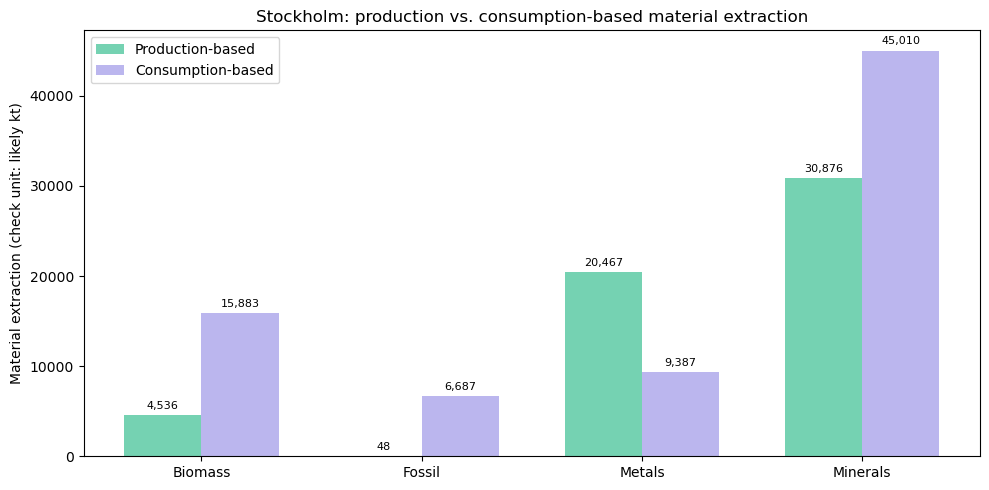

2026-04-13 20:18:30,863 INFO Saved plot: stockholm_material_comparison.png


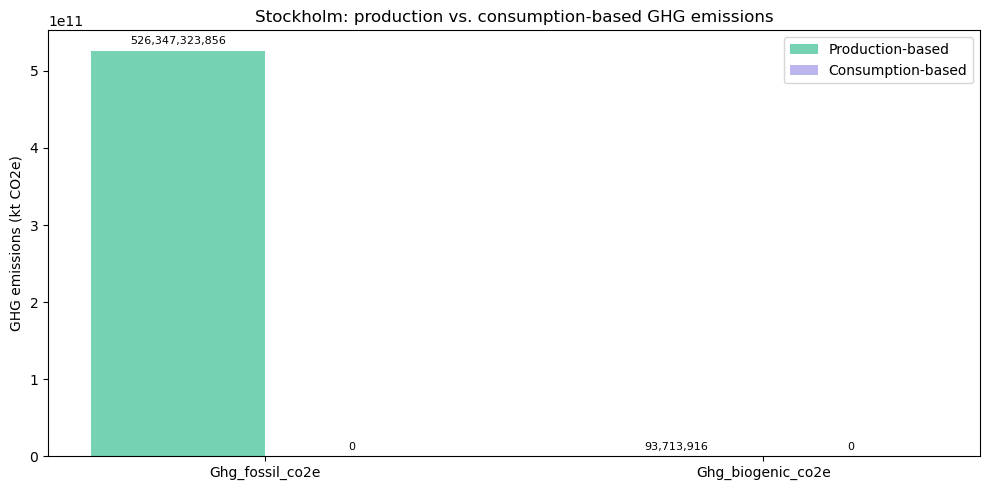

2026-04-13 20:18:31,124 INFO Saved plot: stockholm_ghg_comparison.png


In [14]:
def plot_pba_vs_cba(data, title, ylabel, filename):
    """Side-by-side bar chart comparing PBA and CBA for Stockholm."""
    categories = data['pba_sthlm'].index.tolist()
    pba = data['pba_sthlm'].values
    cba = data['cba_sthlm'].values

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, pba, width, label='Production-based',
                   color='#5DCAA5', alpha=0.85)
    bars2 = ax.bar(x + width/2, cba, width, label='Consumption-based',
                   color='#AFA9EC', alpha=0.85)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in categories])
    ax.legend()

    # Add value labels on bars.
    for bar in bars1:
        h = bar.get_height()
        ax.annotate(f'{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        ax.annotate(f'{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f"Saved plot: {filename}")


# Plot material comparison.
if 'material' in results:
    plot_pba_vs_cba(
        results['material'],
        "Stockholm: production vs. consumption-based material extraction",
        "Material extraction (check unit: likely kt)",
        "stockholm_material_comparison.png"
    )

# Plot GHG comparison.
if 'ghg' in results:
    plot_pba_vs_cba(
        results['ghg'],
        "Stockholm: production vs. consumption-based GHG emissions",
        "GHG emissions (kt CO2e)",
        "stockholm_ghg_comparison.png"
    )

## Summary for workshop

Print a concise summary of the key findings.

In [15]:
print("=" * 65)
print("WORKSHOP SUMMARY: Stockholm preliminary disaggregation results")
print("=" * 65)
print(f"Base year: {BASE_YEAR}")
print(f"Demand weight (Stockholm share of SE final demand): {DEMAND_WEIGHT_STHLM:.0%}")
print()

if 'material' in results:
    print("--- Material extraction (Anthesis categories) ---")
    print(f"{'Category':>12s}  {'PBA':>12s}  {'CBA':>12s}  {'Net':>12s}  Direction")
    print("-" * 65)
    for cat in results['material']['pba_sthlm'].index:
        pba = results['material']['pba_sthlm'][cat]
        cba = results['material']['cba_sthlm'][cat]
        net = pba - cba
        direction = "net exporter" if net > 0 else "NET IMPORTER"
        print(f"{cat:>12s}  {pba:>12,.1f}  {cba:>12,.1f}  {net:>12,.1f}  {direction}")
    print()

if 'ghg' in results:
    print("--- GHG emissions ---")
    print(f"{'Category':>20s}  {'PBA':>12s}  {'CBA':>12s}  {'Net':>12s}  Direction")
    print("-" * 65)
    for cat in results['ghg']['pba_sthlm'].index:
        pba = results['ghg']['pba_sthlm'][cat]
        cba = results['ghg']['cba_sthlm'][cat]
        net = pba - cba
        direction = "net exporter" if net > 0 else "NET IMPORTER"
        print(f"{cat:>20s}  {pba:>12,.1f}  {cba:>12,.1f}  {net:>12,.1f}  {direction}")

print()
print("NOTE: These results use PROXY weights, not actual data.")
print("The direction (net importer/exporter) is the key finding for the workshop.")
print("Absolute values will be refined in the main study with real sector weights.")

WORKSHOP SUMMARY: Stockholm preliminary disaggregation results
Base year: 2024
Demand weight (Stockholm share of SE final demand): 28%

--- Material extraction (Anthesis categories) ---
    Category           PBA           CBA           Net  Direction
-----------------------------------------------------------------
     biomass       4,535.9      15,882.6     -11,346.7  NET IMPORTER
      fossil          48.2       6,686.7      -6,638.5  NET IMPORTER
      metals      20,467.1       9,387.1      11,080.0  net exporter
    minerals      30,876.3      45,009.9     -14,133.6  NET IMPORTER

--- GHG emissions ---
            Category           PBA           CBA           Net  Direction
-----------------------------------------------------------------
     GHG_fossil_CO2e  526,347,323,855.7           0.0  526,347,323,855.7  net exporter
   GHG_biogenic_CO2e  93,713,915.9           0.0  93,713,915.9  net exporter

NOTE: These results use PROXY weights, not actual data.
The direction (net imp

## Sanity check: does the split preserve Sweden's totals?

Verify that Stockholm + Rest-of-Sweden PBA sums back to approximately the original Sweden total.

In [16]:
if 'material' in results:
    pba_sthlm = results['material']['pba_sthlm']
    pba_rest = results['material']['pba_rest']
    pba_combined = pba_sthlm + pba_rest

    print("Sanity check: Stockholm PBA + Rest PBA should ~ Sweden total")
    print(f"{'Category':>12s}  {'Stockholm':>12s}  {'Rest of SE':>12s}  {'Combined':>12s}")
    print("-" * 55)
    for cat in pba_sthlm.index:
        print(f"{cat:>12s}  {pba_sthlm[cat]:>12,.1f}  {pba_rest[cat]:>12,.1f}  "
              f"{pba_combined[cat]:>12,.1f}")

Sanity check: Stockholm PBA + Rest PBA should ~ Sweden total
    Category     Stockholm    Rest of SE      Combined
-------------------------------------------------------
     biomass       4,535.9      59,835.7      64,371.6
      fossil          48.2         152.7         200.9
      metals      20,467.1      64,812.5      85,279.5
    minerals      30,876.3      97,796.4     128,672.7


In [21]:
# =============================================================================
# DIAGNOSTIC CELL — insert after current cell 12 (Sweden sanity check)
# Purpose: identify which gas row is driving GHG inflation before any fix.
# =============================================================================
 
# Per-gas contribution to Sweden's total, in raw kg (before GWP), then in kt CO2e.
# Expected Sweden total: ~45,000 kt CO2e (45 Mt CO2e/year, territorial).
 
air_F_se = exio.air_emissions.F.loc[:, SWEDEN_CODE]
all_rows = air_F_se.index.tolist()
 
print("Per-gas contribution to Sweden total GHG (raw kg summed across sectors)")
print("then converted to kt CO2e using the GWP factor.\n")
print(f"{'Gas':<8}  {'Raw sum (kg)':>22}  {'GWP':>8}  {'kt CO2e':>18}  Note")
print("-" * 80)
 
gas_contributions = {}
 
# CO2 rows (GWP = 1)
co2_rows = [
    "CO2 - combustion - air",
    "CO2 - non combustion - Cement production - air",
    "CO2 - non combustion - Lime production - air",
    "CO2 - waste - fossil - air",
]
co2_raw = sum(air_F_se.loc[r].sum() for r in co2_rows if r in all_rows)
co2_kt = co2_raw * 1 / 1e6
gas_contributions["CO2"] = co2_kt
print(f"{'CO2':<8}  {co2_raw:>22,.0f}  {'1':>8}  {co2_kt:>18,.1f}")
 
# CH4 rows (GWP = 28)
ch4_rows = [
    "CH4 - combustion - air",
    "CH4 - non combustion - Extraction/production of (natural) gas - air",
    "CH4 - non combustion - Extraction/production of crude oil - air",
    "CH4 - non combustion - Mining of antracite - air",
    "CH4 - non combustion - Mining of bituminous coal - air",
    "CH4 - non combustion - Mining of coking coal - air",
    "CH4 - non combustion - Mining of lignite (brown coal) - air",
    "CH4 - non combustion - Mining of sub-bituminous coal - air",
    "CH4 - non combustion - Oil refinery - air",
    "CH4 - agriculture - air",
    "CH4 - waste - air",
]
ch4_raw = sum(air_F_se.loc[r].sum() for r in ch4_rows if r in all_rows)
ch4_kt = ch4_raw * 28 / 1e6
gas_contributions["CH4"] = ch4_kt
print(f"{'CH4':<8}  {ch4_raw:>22,.0f}  {'28':>8}  {ch4_kt:>18,.1f}")
 
# N2O rows (GWP = 265)
n2o_rows = ["N2O - combustion - air", "N2O - agriculture - air"]
n2o_raw = sum(air_F_se.loc[r].sum() for r in n2o_rows if r in all_rows)
n2o_kt = n2o_raw * 265 / 1e6
gas_contributions["N2O"] = n2o_kt
print(f"{'N2O':<8}  {n2o_raw:>22,.0f}  {'265':>8}  {n2o_kt:>18,.1f}")
 
# SF6 — show both with and without GWP to diagnose
sf6_raw = air_F_se.loc["SF6 - air"].sum() if "SF6 - air" in all_rows else 0.0
sf6_kt_gwp = sf6_raw * 23500 / 1e6
sf6_kt_raw = sf6_raw / 1e6  # as if already CO2e
gas_contributions["SF6"] = sf6_kt_gwp
note_sf6 = "<< CHECK if already CO2e" if sf6_kt_gwp > 5000 else "OK"
print(f"{'SF6':<8}  {sf6_raw:>22,.0f}  {'23500':>8}  {sf6_kt_gwp:>18,.1f}  {note_sf6}")
print(f"{'SF6*':<8}  {'(if GWP=1)':>22}  {'1':>8}  {sf6_kt_raw:>18,.1f}  (for comparison)")
 
# HFC — same
hfc_raw = air_F_se.loc["HFC - air"].sum() if "HFC - air" in all_rows else 0.0
hfc_kt_gwp = hfc_raw * 1300 / 1e6
hfc_kt_raw = hfc_raw / 1e6
gas_contributions["HFC"] = hfc_kt_gwp
note_hfc = "<< CHECK if already CO2e" if hfc_kt_gwp > 5000 else "OK"
print(f"{'HFC':<8}  {hfc_raw:>22,.0f}  {'1300':>8}  {hfc_kt_gwp:>18,.1f}  {note_hfc}")
print(f"{'HFC*':<8}  {'(if GWP=1)':>22}  {'1':>8}  {hfc_kt_raw:>18,.1f}  (for comparison)")
 
# PFC — same
pfc_raw = air_F_se.loc["PFC - air"].sum() if "PFC - air" in all_rows else 0.0
pfc_kt_gwp = pfc_raw * 7000 / 1e6
pfc_kt_raw = pfc_raw / 1e6
gas_contributions["PFC"] = pfc_kt_gwp
note_pfc = "<< CHECK if already CO2e" if pfc_kt_gwp > 5000 else "OK"
print(f"{'PFC':<8}  {pfc_raw:>22,.0f}  {'7000':>8}  {pfc_kt_gwp:>18,.1f}  {note_pfc}")
print(f"{'PFC*':<8}  {'(if GWP=1)':>22}  {'1':>8}  {pfc_kt_raw:>18,.1f}  (for comparison)")
 
print("-" * 80)
total_with_gwp = sum(gas_contributions.values())
print(f"\nTotal with current GWP factors: {total_with_gwp:>18,.1f} kt CO2e")
print(f"Expected Sweden territorial GHG: ~45,000 kt CO2e")
print(f"Inflation factor: {total_with_gwp / 45000:.1f}x")
print(f"\nIf SF6/HFC/PFC are already in CO2e (GWP=1 for all three):")
total_corrected = co2_kt + ch4_kt + n2o_kt + sf6_kt_raw + hfc_kt_raw + pfc_kt_raw
print(f"  Corrected total: {total_corrected:>18,.1f} kt CO2e")

Per-gas contribution to Sweden total GHG (raw kg summed across sectors)
then converted to kt CO2e using the GWP factor.

Gas                 Raw sum (kg)       GWP             kt CO2e  Note
--------------------------------------------------------------------------------
CO2                1,662,314,459         1             1,662.3
CH4                  616,185,003        28            17,253.2
N2O                   17,441,428       265             4,622.0
SF6                        1,975     23500                46.4  OK
SF6*                  (if GWP=1)         1                 0.0  (for comparison)
HFC                1,311,306,422      1300         1,704,698.3  << CHECK if already CO2e
HFC*                  (if GWP=1)         1             1,311.3  (for comparison)
PFC                   98,160,627      7000           687,124.4  << CHECK if already CO2e
PFC*                  (if GWP=1)         1                98.2  (for comparison)
----------------------------------------------------